# Cookie Cats A/B Test Analysis

### Measuring the Impact of Game Gate Placement on Player Retention

**Tools:** Python, Pandas, NumPy, SciPy, Statsmodels, Matplotlib, Seaborn

---

## Business Question

Should Cookie Cats move its first progression gate from level 30 to level 40?

## Primary Metric

7-day player retention

## Secondary Metrics

- 1-day retention
- Total game rounds played

## 1. Business Context

Cookie Cats is a mobile puzzle game in which players progress through a
sequence of levels.

The product team tested two versions of the game to evaluate whether the
location of the first progression gate affected player engagement and
retention.

The experiment compared:

- **Gate 30 (`gate_30`)** — the first progression gate was placed at level 30.
- **Gate 40 (`gate_40`)** — the first progression gate was moved to level 40.

The objective of this analysis is to determine whether the change in gate
placement produced a meaningful difference in player retention.

### Analytical Objective

The primary objective is to compare **7-day retention** between the control
and treatment groups.

The analysis will also examine:

- 1-day retention
- Player engagement measured by total game rounds
- Statistical significance
- Effect size
- Confidence intervals

The final analysis will translate the experimental results into a
product-level recommendation.

## 2. Experiment Design & Hypotheses

### Experiment Groups

Players were assigned to one of two experimental configurations:

| Group | Role | Gate Placement |
|---|---|---|
| `gate_30` | Control | First gate at level 30 |
| `gate_40` | Treatment | First gate at level 40 |

The `gate_30` group serves as the baseline against which the `gate_40`
configuration is evaluated.

### Primary Metric

**7-day retention** is the primary outcome metric.

This metric indicates whether a player returned to the game seven days after
installation and is used as the main basis for the product decision.

### Hypotheses

**Null Hypothesis (H₀):**

There is no difference in 7-day retention between the gate-30 and gate-40
groups.

**Alternative Hypothesis (H₁):**

There is a difference in 7-day retention between the gate-30 and gate-40
groups.

The analysis uses a significance level of **α = 0.05**.

Because the primary outcome is binary and the experiment compares two
independent groups, a two-proportion hypothesis test will be used to evaluate
the difference in 7-day retention.

## 3. Data Loading & Initial Overview

The dataset contains one record per player and captures the experimental
assignment, total game rounds played, and 1-day and 7-day retention outcomes.

The dataset is loaded directly into a pandas DataFrame for validation and
analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep


sns.set_theme(style="whitegrid")


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
df = pd.read_csv("cookie_cats.csv")

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully: 90,189 rows × 5 columns


## 4. Data Quality & Experiment Validation

Before analyzing the experiment results, the dataset was validated for
completeness, uniqueness, and correct experiment assignment.

The validation checks confirm:

- No missing values
- No duplicate records
- One record per unique player
- Two valid experiment groups (`gate_30` and `gate_40`)
- Binary retention outcomes (`True` / `False`)
- Approximately balanced experiment-group allocation

In [10]:
# Validate dataset quality and experiment structure

quality_summary = pd.DataFrame({
    "Check": [
        "Total records",
        "Unique users",
        "Duplicate rows",
        "Duplicate user IDs",
        "Missing values",
        "Experiment groups"
    ],
    "Result": [
        f"{len(df):,}",
        f"{df['userid'].nunique():,}",
        f"{df.duplicated().sum():,}",
        f"{df['userid'].duplicated().sum():,}",
        f"{df.isnull().sum().sum():,}",
        ", ".join(sorted(df["version"].unique()))
    ]
})

display(quality_summary.style.hide(axis="index"))

# Experiment group distribution
group_summary = (
    df["version"]
    .value_counts()
    .rename_axis("Experiment Group")
    .reset_index(name="Players")
)

group_summary["Share (%)"] = (
    group_summary["Players"] / len(df) * 100
).round(2)

display(group_summary.style.hide(axis="index"))
# Validate retention variables
print("1-day retention values:", sorted(df["retention_1"].unique()))
print("7-day retention values:", sorted(df["retention_7"].unique()))

Check,Result
Total records,"90,189"
Unique users,"90,189"
Duplicate rows,0
Duplicate user IDs,0
Missing values,0
Experiment groups,"gate_30, gate_40"


Experiment Group,Players,Share (%)
gate_40,45489,50.440000
gate_30,44700,49.560000


1-day retention values: [np.False_, np.True_]
7-day retention values: [np.False_, np.True_]


## 5. Exploratory Analysis

We begin by comparing player retention across the two experimental groups.

The analysis focuses first on:

- 1-day retention
- 7-day retention

These descriptive comparisons provide the baseline differences between the
control (`gate_30`) and treatment (`gate_40`) groups before formal statistical
testing.

In [4]:
# Calculate retention rates by experiment group

retention_summary = (
    df.groupby("version")[["retention_1", "retention_7"]]
      .mean()
      .mul(100)
      .round(2)
      .rename(columns={
          "retention_1": "1-Day Retention (%)",
          "retention_7": "7-Day Retention (%)"
      })
)

retention_summary

,1-Day Retention (%),7-Day Retention (%)
version,,
gate_30,44.8200,19.0200
gate_40,44.2300,18.2000


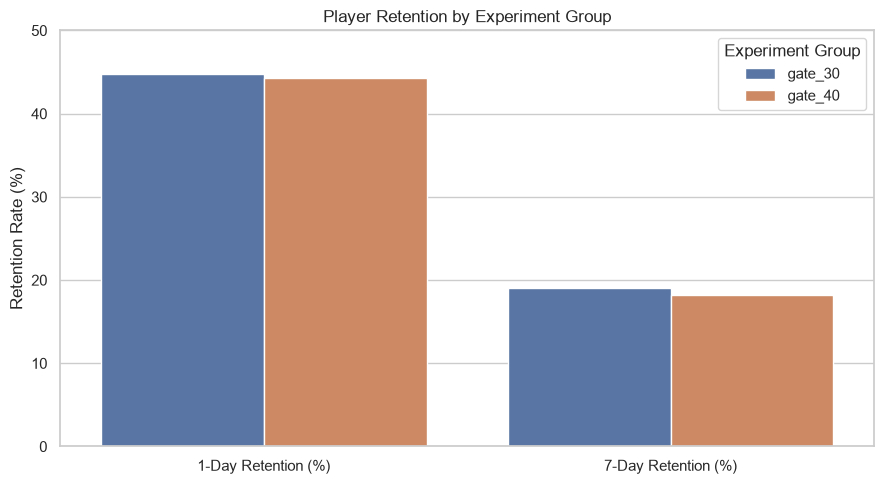

In [5]:
# Visualize retention rates across experiment groups

retention_plot = retention_summary.reset_index().melt(
    id_vars="version",
    var_name="Retention Metric",
    value_name="Retention Rate (%)"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=retention_plot,
    x="Retention Metric",
    y="Retention Rate (%)",
    hue="version"
)

plt.title("Player Retention by Experiment Group")
plt.xlabel("")
plt.ylabel("Retention Rate (%)")
plt.ylim(0, 50)
plt.legend(title="Experiment Group")

plt.tight_layout()
plt.show()

## 6. Statistical Testing

Descriptive differences alone are not sufficient to determine whether the
experiment produced a meaningful change.

Because both retention metrics are binary outcomes, we compare the retention
proportions between the two independent experiment groups using a
**two-proportion z-test**.

### Testing Framework

For each retention metric:

- **H₀:** Retention is equal between `gate_30` and `gate_40`.
- **H₁:** Retention differs between `gate_30` and `gate_40`.
- **Significance level:** α = 0.05

The **7-day retention test is the primary statistical test**, while
1-day retention is treated as a secondary metric.

In [6]:
# Two-proportion z-tests for 1-day and 7-day retention

test_results = []

for metric in ["retention_1", "retention_7"]:
    control = df.loc[df["version"] == "gate_30", metric]
    treatment = df.loc[df["version"] == "gate_40", metric]

    successes = np.array([
        control.sum(),
        treatment.sum()
    ])

    sample_sizes = np.array([
        len(control),
        len(treatment)
    ])

    z_stat, p_value = proportions_ztest(
        count=successes,
        nobs=sample_sizes,
        alternative="two-sided"
    )

    test_results.append({
        "Metric": metric,
        "Control Rate (%)": control.mean() * 100,
        "Treatment Rate (%)": treatment.mean() * 100,
        "Difference (pp)": (treatment.mean() - control.mean()) * 100,
        "Z-Statistic": z_stat,
        "P-Value": p_value,
        "Significant (α=0.05)": "Yes" if p_value < 0.05 else "No"
    })

test_results_df = pd.DataFrame(test_results)

test_results_df.round(4)

,Metric,Control Rate (%),Treatment Rate (%),Difference (pp),Z-Statistic,P-Value,Significant (α=0.05)
0,retention_1,44.8188,44.2283,-0.5905,1.7841,0.0744,No
1,retention_7,19.0201,18.2000,-0.8201,3.1644,0.0016,Yes


In [7]:
# Calculate effect sizes and 95% confidence intervals

control = df.loc[df["version"] == "gate_30", "retention_7"]
treatment = df.loc[df["version"] == "gate_40", "retention_7"]

control_rate = control.mean()
treatment_rate = treatment.mean()

# Absolute difference: treatment - control
absolute_difference = treatment_rate - control_rate

# Relative change: (treatment - control) / control
relative_change = absolute_difference / control_rate

# 95% confidence interval for treatment - control
ci_low, ci_high = confint_proportions_2indep(
    count1=treatment.sum(),
    nobs1=len(treatment),
    count2=control.sum(),
    nobs2=len(control),
    compare="diff",
    method="wald",
    alpha=0.05
)

effect_summary = pd.DataFrame({
    "Metric": [
        "Control 7-Day Retention",
        "Treatment 7-Day Retention",
        "Absolute Difference",
        "Relative Change",
        "95% CI Lower",
        "95% CI Upper"
    ],
    "Value": [
        control_rate * 100,
        treatment_rate * 100,
        absolute_difference * 100,
        relative_change * 100,
        ci_low * 100,
        ci_high * 100
    ]
})

effect_summary.style.format({
    "Value": "{:.2f}%"
}).hide(axis="index")

Metric,Value
Control 7-Day Retention,19.02%
Treatment 7-Day Retention,18.20%
Absolute Difference,-0.82%
Relative Change,-4.31%
95% CI Lower,-1.33%
95% CI Upper,-0.31%


## 7. Secondary Analysis: Player Engagement

Retention is the primary outcome, but total game rounds provide an additional
view of player engagement.

Because game-round counts can be highly right-skewed, the analysis compares
the **median** and **distribution** of game rounds between the two experiment
groups.

A Mann–Whitney U test is used to assess whether the distributions differ
between `gate_30` and `gate_40`.

In [8]:
# Compare player engagement across experiment groups

engagement_summary = (
    df.groupby("version")["sum_gamerounds"]
      .agg(
          Median="median",
          Mean="mean",
          Players="count"
      )
      .round(2)
)

# Mann–Whitney U test
control_rounds = df.loc[df["version"] == "gate_30", "sum_gamerounds"]
treatment_rounds = df.loc[df["version"] == "gate_40", "sum_gamerounds"]

u_stat, p_value = stats.mannwhitneyu(
    control_rounds,
    treatment_rounds,
    alternative="two-sided"
)

print("Engagement Summary")
display(engagement_summary)

print(f"Mann–Whitney U statistic: {u_stat:,.0f}")
print(f"P-value: {p_value:.4f}")
print(
    f"Statistically significant at α=0.05: "
    f"{'Yes' if p_value < 0.05 else 'No'}"
)

Engagement Summary


,Median,Mean,Players
version,,,
gate_30,17.0000,52.4600,44700
gate_40,16.0000,51.3000,45489


Mann–Whitney U statistic: 1,024,331,250
P-value: 0.0502
Statistically significant at α=0.05: No


## 8. Results Summary

The experiment results are evaluated across the primary retention metric and
the secondary engagement metric.

The 7-day retention result is the primary basis for the product decision,
while 1-day retention and game rounds provide supporting context.

In [9]:
# Create a concise summary of the experiment results

results_summary = pd.DataFrame({
    "Metric": [
        "1-Day Retention",
        "7-Day Retention",
        "Game Rounds"
    ],
    "Gate 30": [
        f"{retention_summary.loc['gate_30', '1-Day Retention (%)']:.2f}%",
        f"{retention_summary.loc['gate_30', '7-Day Retention (%)']:.2f}%",
        f"{engagement_summary.loc['gate_30', 'Median']:.0f} median"
    ],
    "Gate 40": [
        f"{retention_summary.loc['gate_40', '1-Day Retention (%)']:.2f}%",
        f"{retention_summary.loc['gate_40', '7-Day Retention (%)']:.2f}%",
        f"{engagement_summary.loc['gate_40', 'Median']:.0f} median"
    ],
    "P-Value": [
        f"{test_results_df.loc[0, 'P-Value']:.4f}",
        f"{test_results_df.loc[1, 'P-Value']:.4f}",
        f"{p_value:.4f}"
    ],
    "Significant": [
        test_results_df.loc[0, "Significant (α=0.05)"],
        test_results_df.loc[1, "Significant (α=0.05)"],
        "No"
    ]
})

results_summary.style.hide(axis="index")

Metric,Gate 30,Gate 40,P-Value,Significant
1-Day Retention,44.82%,44.23%,0.0744,No
7-Day Retention,19.02%,18.20%,0.0016,Yes
Game Rounds,17 median,16 median,0.0502,No


## 9. Business Recommendation

### Primary Finding

The `gate_40` configuration produced lower 7-day retention than `gate_30`:

- `gate_30`: **19.02%**
- `gate_40`: **18.20%**
- Absolute difference: **−0.82 percentage points**
- Relative change: **−4.31%**
- 95% CI: **−1.33 to −0.31 percentage points**
- p-value: **0.0016**

The difference is statistically significant at the 5% significance level.

### Recommendation

Based on the experiment results, **do not roll out the gate-40 configuration
as the default experience**.
The gate-40 configuration produced a statistically significant decrease in 7-day retention relative to gate-30.

A reasonable next step would be to retain the gate-30 configuration while
testing alternative gate placements or additional product variations.

### Business Interpretation

The experiment suggests that moving the first progression gate from level 30
to level 40 did not improve player retention. The strongest evidence comes
from the 7-day retention metric, which was the predefined primary outcome.

## 10. Limitations & Interpretation

While the experiment provides evidence that the gate-40 configuration is
associated with lower 7-day retention in this dataset, several limitations
should be considered.

- **Experiment scope:** The conclusions apply to the population represented
  in this experiment and the outcomes measured in the dataset.
- **Primary metric focus:** The product decision is based primarily on
  7-day retention, while other potential business outcomes are not included.
- **Engagement metric:** Game rounds are highly variable, so the median and
  Mann–Whitney U test provide a more robust comparison than relying only on
  the mean.
- **Statistical significance vs. business impact:** Statistical significance
  does not by itself determine the financial or long-term business impact of
  a change.
- **Multiple product factors:** Player behavior may be influenced by factors
  beyond gate placement that are not evaluated in this analysis.

### Interpretation

The evidence supports a negative difference in 7-day retention for the
gate-40 configuration within this experiment. Further experimentation could
test alternative gate placements or product designs before making a broader
product change.

## 11. Executive Takeaway

### Key Finding

Moving the first progression gate from level 30 to level 40 did **not** improve
player retention.

The gate-40 group recorded:

- **18.20%** 7-day retention vs. **19.02%** for gate-30
- **−0.82 percentage-point** absolute difference
- **−4.31%** relative change
- **p = 0.0016**
- **95% CI: −1.33 to −0.31 percentage points**

The difference in 1-day retention was not statistically significant
(**p = 0.0744**), and the difference in median game rounds was also not
statistically significant (**p = 0.0502**).

### Product Decision

Based on the primary metric, the analysis recommends **retaining the gate-30
configuration rather than rolling out gate-40**.

Future experimentation could evaluate alternative gate placements and measure
their impact on retention and player engagement.

---

